In [33]:
# 0. 라이브러리 + 데이터 불러오기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_temp = pd.read_csv(
    "c:/Users/82107/OneDrive/바탕 화면/수업자료/프로젝트 준비/01_원본데이터/eaf_temp.csv"
)

In [34]:
# 1. 데이터 기본 구조 확인

print("데이터 크기 :", df_temp.shape)
print("컬럼명 :", df_temp.columns)

display(df_temp.head())

df_temp.info()

데이터 크기 : (85104, 4)
컬럼명 : Index(['HEATID', 'DATETIME', 'TEMP', 'VALO2_PPM'], dtype='str')


,HEATID,DATETIME,TEMP,VALO2_PPM
0,6F0020,2016-01-01 19:15:00,1650.0,1242.0
1,6F0021,2016-01-01 20:05:00,1649.0,1160.0
2,6F0021,2016-01-01 20:05:00,1649.0,1160.0
3,6F0021,2016-01-01 20:03:00,1606.0,1152.0
4,6F0022,2016-01-01 21:03:00,1636.0,947.0


<class 'pandas.DataFrame'>
RangeIndex: 85104 entries, 0 to 85103
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HEATID     85104 non-null  str    
 1   DATETIME   85104 non-null  str    
 2   TEMP       85104 non-null  float64
 3   VALO2_PPM  85104 non-null  float64
dtypes: float64(2), str(2)
memory usage: 2.6 MB


In [35]:
# 2. 기본 품질 확인

print("결측치 개수")
print(df_temp.isna().sum())

print()

print("완전 중복 행 수 :", df_temp.duplicated().sum())

print()

print("전체 Heat 수 :", df_temp["HEATID"].nunique())

결측치 개수
HEATID       0
DATETIME     0
TEMP         0
VALO2_PPM    0
dtype: int64

완전 중복 행 수 : 1808

전체 Heat 수 : 20827


In [36]:
# 3. DATETIME 변환

df_temp["DATETIME"] = pd.to_datetime(df_temp["DATETIME"])

df_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 85104 entries, 0 to 85103
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   HEATID     85104 non-null  str           
 1   DATETIME   85104 non-null  datetime64[us]
 2   TEMP       85104 non-null  float64       
 3   VALO2_PPM  85104 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 2.6 MB


In [37]:
# 4. HEATID별 측정 구조 확인

print("Heat별 측정 횟수 TOP 10")

display(
    df_temp["HEATID"]
    .value_counts()
    .head(10)
)

print("Heat당 측정 횟수 통계")

display(
    df_temp.groupby("HEATID")
    .size()
    .describe()
)

Heat별 측정 횟수 TOP 10


HEATID
6F8269    48
5F5306    48
5F0112    46
5F7240    45
5F7221    35
6F4696    32
7F0057    31
6F2665    28
6F2667    28
6F7323    28
Name: count, dtype: int64

Heat당 측정 횟수 통계


count    20827.000000
mean         4.086234
std          2.266707
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         48.000000
dtype: float64

In [38]:
# 5. 중복 데이터 실제 확인

dup = df_temp[
    df_temp.duplicated(keep=False)
].sort_values(
    ["HEATID", "DATETIME"]
)

display(dup.head(20))

,HEATID,DATETIME,TEMP,VALO2_PPM
60186,5F0006,2015-01-01 04:53:00,1620.0,624.0
60187,5F0006,2015-01-01 04:53:00,1620.0,624.0
60191,5F0008,2015-01-01 07:34:00,1605.0,538.0
60192,5F0008,2015-01-01 07:34:00,1605.0,538.0
60280,5F0045,2015-01-02 15:42:00,1649.0,51.0
60282,5F0045,2015-01-02 15:42:00,1649.0,51.0
60277,5F0045,2015-01-02 15:43:00,1649.0,51.0
60278,5F0045,2015-01-02 15:43:00,1649.0,51.0
60303,5F0051,2015-01-03 04:11:00,1624.0,440.0
60306,5F0051,2015-01-03 04:11:00,1624.0,440.0


In [39]:
# 6. 특정 HEAT의 시간 흐름 확인

one_heat = df_temp[
    df_temp["HEATID"] == "6F8269"
].sort_values("DATETIME")

display(one_heat)

,HEATID,DATETIME,TEMP,VALO2_PPM
34885,6F8269,2016-12-21 11:37:00,1658.0,1041.0
34884,6F8269,2016-12-21 11:37:00,1658.0,1041.0
34866,6F8269,2016-12-21 11:38:00,1658.0,1041.0
34865,6F8269,2016-12-21 11:38:00,1658.0,1041.0
34867,6F8269,2016-12-21 11:39:00,1658.0,1041.0
34870,6F8269,2016-12-21 11:40:00,1658.0,1041.0
34869,6F8269,2016-12-21 11:40:00,1658.0,1041.0
34868,6F8269,2016-12-21 11:40:00,1658.0,1041.0
34873,6F8269,2016-12-21 11:41:00,1658.0,1041.0
34871,6F8269,2016-12-21 11:41:00,1658.0,1041.0


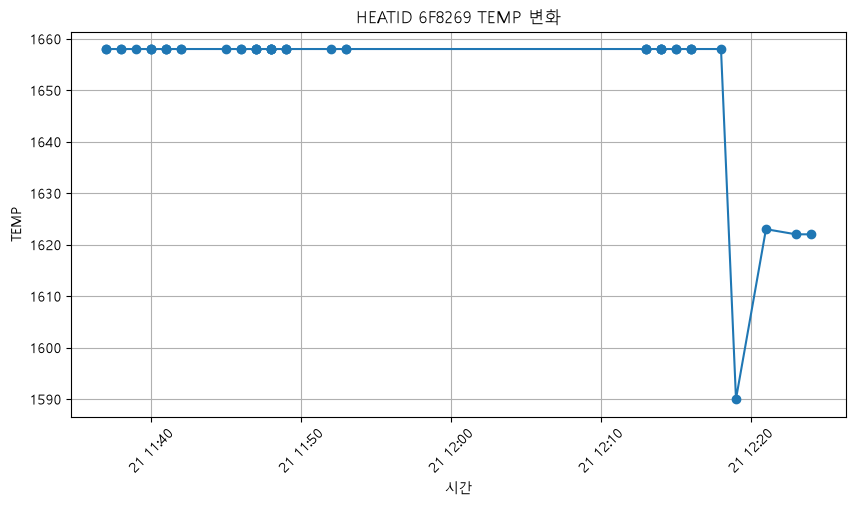

In [40]:
# 7. 특정 HEAT의 TEMP 변화 그래프

plt.figure(figsize=(10, 5))

plt.plot(
    one_heat["DATETIME"],
    one_heat["TEMP"],
    marker="o"
)

plt.title("HEATID 6F8269 TEMP 변화")
plt.xlabel("시간")
plt.ylabel("TEMP")
plt.xticks(rotation=45)
plt.grid()

plt.show()